# 6c Visualization absence

## 1 Setup

### Load libraries

In [1]:
library(readxl)
library(tidyverse)
library(colorspace)
library(colorspace)
library(ggrepel)
library(patchwork)
library(svglite)
library(IRdisplay)
library(ggvenn)
library(ComplexUpset)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid



### Setup workspace

In [ ]:
# Set working directory to project folder
wd <- "/path/to/02_metabolomics"
setwd(wd)

## 2 Load data

### Load feature table

In [3]:
ft_filePath <- file.path(wd, "04_analysis", "tables", "featureTable.csv")
ft <- read.csv(ft_filePath)

### Define parameters and colors

In [4]:
# Map raw identifiers to cleaned or display-friendly names
rename_pks <- c(
  "disfp" = "disfp",
  "pks5" = "pks5",
  "pks5_xenic" = "pks5 (xenic)",
  "pks7" = "pks7",
  "pks24" = "pks24",
  "pks25" = "pks25",
  "pks2425" = "pks24 & pks25",
  "pks24andpks25" = "pks24/pks25" ,
  "pks24_pks25_pks2425" = "pks24 & pks25 & pks24/pks25"
)

# Define NPClassifier category colors
NPC_pathway.colors <- c(
  "Alkaloids" = "#8DD3C7",
  "Amino acids and Peptides" = "#FFD92F",
  "Carbohydrates" = "#386CB0",
  "Fatty acids" = "#F781BF",
  "Polyketides" = "#FF7F00",
  "Shikimates and Phenylpropanoids" = "#A6761D",
  "Terpenoids" = "#7FC97F",
  "unknown" = "#CCCCCC"
)

# Define category order for plotting
NPC_pathway.levels <- c(
  "Alkaloids",
  "Amino acids and Peptides",
  "Carbohydrates",
  "Fatty acids",
  "Polyketides",
  "Shikimates and Phenylpropanoids",
  "Terpenoids",
  "unknown",
  "others"
)


## 3 Visualization

### Create table for absent features in all stages  
Loop through developmental stages (`veg`, `stv`, `fbs`) to extract features absent in the disfp mutant and compile a combined dataframe of all stage-specific absent features.


In [6]:
stages <- c("veg", "stv", "fbs")

# Extract absent features stage-wise and annotate with stage label
ft_abs_list <- lapply(stages, function(stage) {
  change_col <- paste0("change_", stage)
  mean_col <- paste0(stage, "_wt_mean")

  ft %>%
    filter(.data[[change_col]] == "abs") %>%
    select(
      feature, mode, mz, rt, rt_range.min, rt_range.max,
      !!mean_col, !!change_col,
      sirius_NPC.pathway, sirius_NPC.superclass, sirius_NPC.class,
      sirius_ClassyFire.superclass, sirius_ClassyFire.class, sirius_ClassyFire.subclass,
      metaChange_pks, sirius_smiles
    ) %>%
    rename(
      wt_mean = !!mean_col,
      change = !!change_col
    ) %>%
    mutate(stage = stage)
})

# Combine all into one table
ft_abs <- bind_rows(ft_abs_list)


### Absent features across developmental stages  
Visualize features absent in the disfp mutant across vegetative cells, starved cells, and fruiting bodies. Top features are highlighted, and compound classes are color-coded based on NPClassifier annotations.


Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”
Warning message:
“The `labeller` API has been updated. Labellers taking `variable` and `value`
arguments are now deprecated.
ℹ See labellers documentation.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


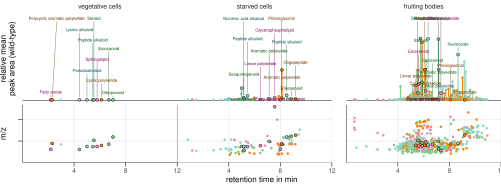

In [15]:
# Rename stages and compound classes for faceting and labeling
rename_stage_dict <- list(
  "veg" = "vegetative cells",
  "stv" = "starved cells",
  "fbs" = "fruiting bodies",
  "Alkaloids" = "Alkaloids",
  "Amino acids and Peptides" = "Amino acids and \n Peptides",
  "Carbohydrates" = "Carbohydrates",
  "Fatty acids" = "Fatty acids",
  "unknown" = "unknown",
  "Polyketides" = "Polyketides",
  "Shikimates and Phenylpropanoids" = "Shikimates and \n Phenylpropanoids",
  "Terpenoids" = "Terpenoids"
)

labeller <- function(variable, value) rename_stage_dict[value]

# Define color palette
NPC_pathway.colors <- c(
  "Alkaloids" = "#8DD3C7",
  "Amino acids and Peptides" = "#FFD92F",
  "Carbohydrates" = "#386CB0",
  "Fatty acids" = "#F781BF",
  "unknown" = "#CCCCCC",
  "Polyketides" = "#FF7F00",
  "Shikimates and Phenylpropanoids" = "#A6761D",
  "Terpenoids" = "#7FC97F"
)

# Create dark variants for labeling
NPC_pathway.colors.dark <- darken(NPC_pathway.colors, amount = 0.6)
names(NPC_pathway.colors.dark) <- paste0(names(NPC_pathway.colors), "_dark")

# Background panel structure for selected pathways
background_data <- expand.grid(
  sirius_NPC.pathway = unique(ft_abs$sirius_NPC.pathway),
  stage = unique(ft_abs$stage)
) %>%
  filter(sirius_NPC.pathway %in% c("Alkaloids", "Fatty acids", "Polyketides", "Terpenoids")) %>%
  mutate(fill = NPC_pathway.colors[sirius_NPC.pathway])

# Identify top N features per stage and pathway
top_n <- 3
top_features <- ft_abs %>%
  filter(sirius_NPC.pathway %in% c("Alkaloids", "Fatty acids", "Polyketides", "Terpenoids")) %>%
  filter(sirius_NPC.pathway %in% NPC_pathway.levels) %>%
  group_by(stage, sirius_NPC.pathway) %>%
  arrange(desc(wt_mean)) %>%
  distinct(sirius_NPC.superclass, .keep_all = TRUE) %>%
  slice_head(n = top_n) %>%
  pull(feature)

# Mark top features in full dataset
ft_selected <- ft_abs %>%
  filter(sirius_NPC.pathway %in% c("Alkaloids", "Fatty acids", "Polyketides", "Terpenoids")) %>%
  mutate(
    NPC_pathway.levels = factor(sirius_NPC.pathway, levels = NPC_pathway.levels),
    top_n_flag = feature %in% top_features
  ) %>%
  arrange(stage, top_n_flag, desc(wt_mean))

# Plot 1: intensity vs. RT
npc_plot_stages_int <- ft_selected %>%
  mutate(stage = factor(stage, levels = c("veg", "stv", "fbs"))) %>%
  ggplot(aes(x = rt, y = wt_mean)) +
  geom_segment(aes(x = rt, y = -250000, yend = wt_mean, color = sirius_NPC.pathway), linewidth = 0.5) +
  annotate("segment", x = 0, xend = 12, y = -250000, yend = -250000, color = "black", linewidth = 0.2) +
  geom_point(shape = 21, color = "black", size = 1.2, aes(stroke = ifelse(top_n_flag, 0.3, 0), fill = sirius_NPC.pathway)) +
  geom_text_repel(
    data = ~.x %>% filter(top_n_flag),
    aes(
      label = str_replace(sub("s$", "", sirius_NPC.superclass), " and derivatives", ""),
      color = paste0(sirius_NPC.pathway, "_dark")
    ),
    size = 1.5, box.padding = 0.3, segment.alpha = 0.75, segment.size = 0.2,
    point.padding = 0.5, max.overlaps = Inf, min.segment.length = 0,
    force = 100, force_pull = 40, direction = "y"
  ) +
  scale_fill_manual(values = NPC_pathway.colors) +
  scale_color_manual(values = c(NPC_pathway.colors, NPC_pathway.colors.dark)) +
  facet_grid(~stage, switch = "y", labeller = labeller) +
  labs(x = NULL, y = "relative mean \npeak area (wild-type)") +
  scale_y_continuous(labels = NULL) +
  scale_x_continuous(breaks = NULL, limits = c(0, 12), expand = c(0, 0)) +
  coord_cartesian(ylim = c(NA, 3e7)) +
  theme_minimal(base_size = 8) +
  theme(
    strip.placement = "outside",
    strip.text.y.left = element_text(angle = 0, hjust = 1),
    panel.spacing = unit(c(0, 1), "lines"),
    panel.grid = element_blank(),
    strip.background = element_blank(),
    legend.position = "none"
  )

# Plot 2: mz vs. RT
npc_plot_stages_mz <- ft_selected %>%
  mutate(stage = factor(stage, levels = c("veg", "stv", "fbs"))) %>%
  ggplot(aes(x = rt, y = mz)) +
  annotate("segment", x = 0, xend = 12, y = 0, yend = 0, color = "black", linewidth = 0.2) +
  annotate("segment", x = 0, xend = 0, y = 0, yend = Inf, color = "black", linewidth = 0.2) +
  geom_point(shape = 21, color = "black", size = 1.2, aes(stroke = ifelse(top_n_flag, 0.3, 0), fill = sirius_NPC.pathway)) +
  scale_fill_manual(values = NPC_pathway.colors) +
  scale_color_manual(values = c(NPC_pathway.colors, NPC_pathway.colors.dark)) +
  facet_grid(~stage, switch = "y", labeller = labeller) +
  labs(x = "retention time in min", y = "m/z") +
  scale_y_continuous(breaks = c(500, 1000), limits = c(0, 1350), expand = c(0, NA), labels = NULL) +
  scale_x_continuous(breaks = c(4, 8, 12), limits = c(0, 12), expand = c(0, 0)) +
  theme_minimal(base_size = 8) +
  theme(
    strip.placement = "outside",
    strip.text = element_blank(),
    panel.spacing = unit(c(0, 1), "lines"),
    axis.ticks = element_line(color = "black", size = 0.25),
    axis.ticks.length = unit(0.15, "cm"),
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    legend.position = "none"
  )

# Combine both plots into one figure
options(repr.plot.width = 15, repr.plot.height = 8)
absent_overview_plot <- wrap_plots(npc_plot_stages_int, npc_plot_stages_mz, ncol = 1, heights = c(2, 1.25)) &
  theme(plot.margin = unit(c(0, 0, 0, 0), "cm"))

# Save to SVG
save_path_svg <- file.path(wd, "05_results", "img", "absent_overview_plot.svg")
ggsave(
  filename = save_path_svg,
  plot = absent_overview_plot,
  width = 177, height = 65, units = "mm",
  bg = "transparent",
  device = svglite
)

# Display the SVG
display_svg(file = save_path_svg)


### Absent feature across pks knockout mutants

#### Binary matrix  
Create a binary matrix indicating absence of each feature across the PKS mutants and the disfp mutant as reference.


In [17]:
# Extract columns related to absence calls across PKS mutants
feature_absent_pks_columns <- grep("^feature_absent_pks", names(ft), value = TRUE)
absent_columns <- c("feature", feature_absent_pks_columns, "change_fbs")

# Build binary matrix (TRUE = absent, FALSE = present)
ft_abs_binary <- ft %>%
  select(all_of(absent_columns)) %>%
  mutate(disfp = if_else(change_fbs == "abs", TRUE, FALSE)) %>%
  select(-change_fbs) %>%
  arrange(feature)

# Use feature ID as row names
row.names(ft_abs_binary) <- as.character(ft_abs_binary$feature)
ft_abs_binary <- ft_abs_binary %>%
  select(-feature)

# Convert all columns to binary integers and clean column names
ft_abs_binary <- as.data.frame(lapply(ft_abs_binary, as.integer))
colnames(ft_abs_binary) <- gsub("^feature_absent_", "", colnames(ft_abs_binary))


#### Venn diagram  
Compare counts  of absent features between the disfp mutant and combined pks knockout mutants.


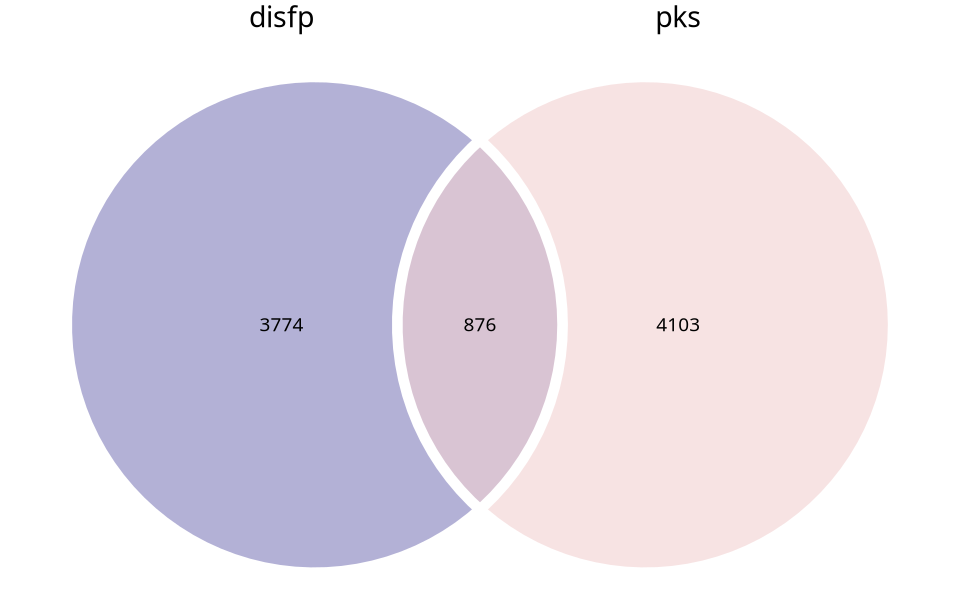

In [18]:
options(repr.plot.width = 8, repr.plot.height = 5)

# Group features absent in disfp and in any PKS mutant
ft_abs_list_combined <- list(
  disfp = which(ft_abs_binary$disfp == 1),
  pks = which(
    ft_abs_binary$pks5 == 1 |
    ft_abs_binary$pks7 == 1 |
    ft_abs_binary$pks24 == 1 |
    ft_abs_binary$pks25 == 1 |
    ft_abs_binary$pks2425 == 1
  )
)

# Plot Venn diagram with custom styling
disfp_pks_venn <- ggvenn(
  ft_abs_list_combined,
  fill_color = c("#807dba", lighten("#614041", amount = 0.8)),
  stroke_size = 3,
  fill_alpha = 0.6,
  stroke_color = "white",
  show_percentage = FALSE,
  set_name_size = 6
) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14)
  )

# Save plot as SVG
save_path_svg <- file.path(wd, "05_results", "img", "disfp_pks_venn.svg")
ggsave(
  filename = save_path_svg,
  plot     = disfp_pks_venn,
  width    = 87, height = 40, units = "mm",
  bg       = "transparent",
  device   = svglite
)

# Display inline
disfp_pks_venn


#### UpSet plot  
Visualize the overlap of absent features between the disfp mutant and selected pks knockouts using a customized UpSet plot.


#### Chromatogram plot with peak area or m/z

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


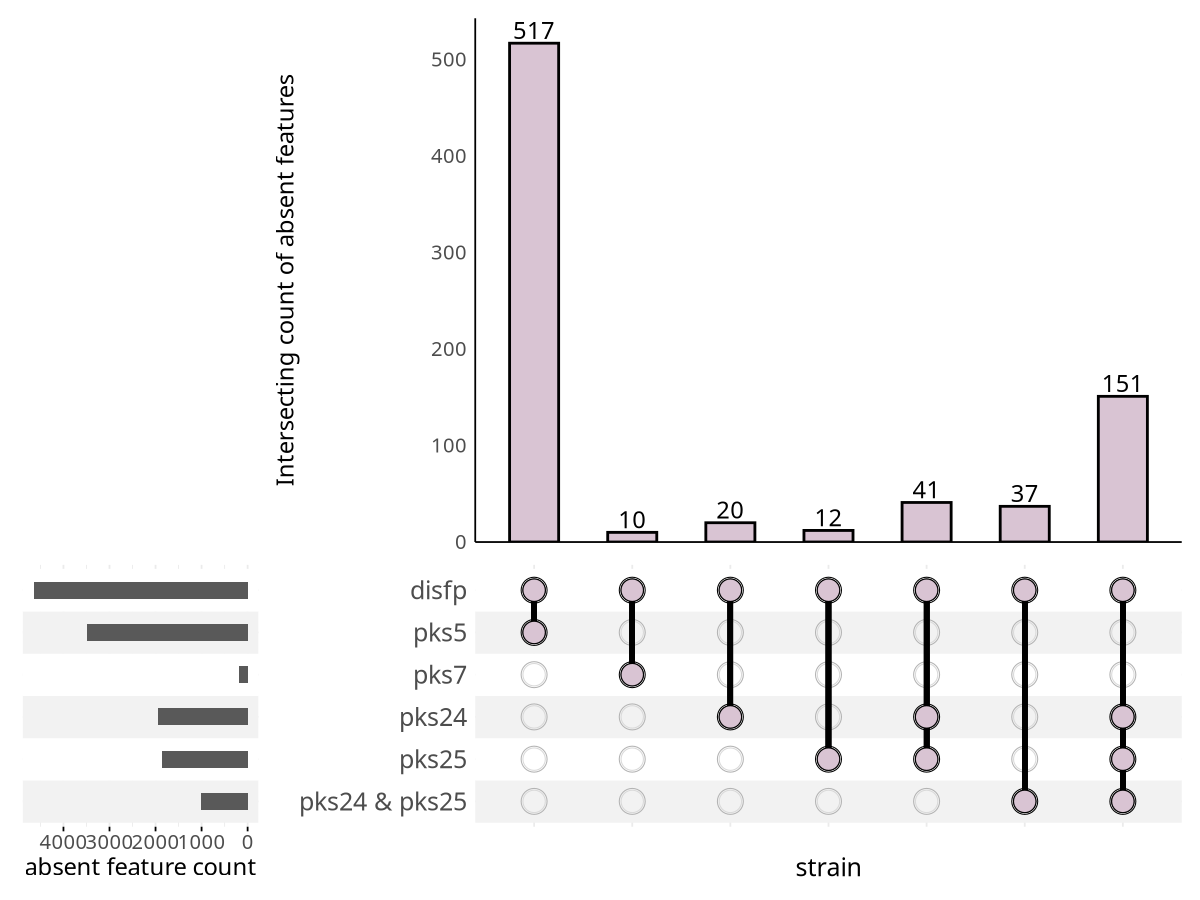

In [19]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

# Create UpSet plot with customized themes and queries for key intersections
upset_pks <- upset(
  ft_abs_binary,
  rev(c("disfp", "pks5", "pks7", "pks24", "pks25", "pks2425")),
  name = "strain",
  labeller = ggplot2::as_labeller(rename_pks),
  intersections = list(
    c("disfp", "pks5"),
    c("disfp", "pks7"),
    c("disfp", "pks24"),
    c("disfp", "pks25"),
    c("disfp", "pks24", "pks25"),
    c("disfp", "pks2425"),
    c("disfp", "pks24", "pks25", "pks2425")
  ),
  queries = lapply(
    list(
      c("disfp", "pks5"),
      c("disfp", "pks7"),
      c("disfp", "pks24"),
      c("disfp", "pks25"),
      c("disfp", "pks24", "pks25"),
      c("disfp", "pks2425"),
      c("disfp", "pks24", "pks25", "pks2425")
    ),
    function(intersect_set) {
      upset_query(
        intersect = intersect_set,
        color = "black",
        fill = "#d9c4d3",
        only_components = c("intersections_matrix", "Intersection size", "overall_sizes")
      )
    }
  ),
  sort_intersections = FALSE,
  sort_sets = FALSE,
  width_ratio = 0.25,
  themes = upset_modify_themes(list(
    intersections_matrix = theme(
      axis.text.y = element_text(size = 15),
      axis.title.x = element_text(size = 15)
    )
  )),
  base_annotations = list(
    "Intersection size" = intersection_size(
      text = list(size = 5, check_overlap = TRUE),
      size = 0.8,
      bar_number_threshold = 1,
      width = 0.5
    ) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    labs(y = "Intersecting count of absent features") +
    theme(
      panel.grid = element_blank(),
      axis.line = element_line(colour = "black"),
      axis.title = element_text(size = rel(1.3)),
      axis.text = element_text(size = rel(1.1))
    )
  ),
  stripes = upset_stripes(
    geom = geom_segment(size = 12),
    colors = c("grey95", "white")
  ),
  matrix = intersection_matrix(
    geom = geom_point(shape = "circle filled", size = 6, stroke = 0.45),
    segment = geom_segment(size = 1.5)
  ),
  set_sizes = upset_set_size(
    geom = geom_bar(width = 0.4)
  ) + labs(x = NULL, y = "absent feature count") +
    theme(
      axis.line.x = element_blank(),
      axis.ticks.x = element_line(color = "black"),
      axis.title = element_text(size = rel(1.3)),
      axis.text = element_text(size = rel(1.1))
    )
)

upset_pks


Change scale of the plot elements for SVG export and later editing in Adobe Illustrator.


In [20]:
# Generate a smaller version of the same plot for compact export
upset_pks <- upset(
  ft_abs_binary,
  rev(c("disfp", "pks5", "pks7", "pks24", "pks25", "pks2425")),
  name = "strain",
  labeller = ggplot2::as_labeller(rename_pks),
  intersections = list(
    c("disfp", "pks5"),
    c("disfp", "pks7"),
    c("disfp", "pks24"),
    c("disfp", "pks25"),
    c("disfp", "pks24", "pks25"),
    c("disfp", "pks2425"),
    c("disfp", "pks24", "pks25", "pks2425")
  ),
  queries = lapply(
    list(
      c("disfp", "pks5"),
      c("disfp", "pks7"),
      c("disfp", "pks24"),
      c("disfp", "pks25"),
      c("disfp", "pks24", "pks25"),
      c("disfp", "pks2425"),
      c("disfp", "pks24", "pks25", "pks2425")
    ),
    function(intersect_set) {
      upset_query(
        intersect = intersect_set,
        color = "black",
        fill = "#d9c4d3",
        only_components = c("intersections_matrix", "Intersection size", "overall_sizes")
      )
    }
  ),
  sort_intersections = FALSE,
  sort_sets = FALSE,
  width_ratio = 0.2,
  height_ratio = 1.5,
  themes = upset_modify_themes(list(
    intersections_matrix = theme(
      axis.text.y = element_text(size = 8),
      axis.title.x = element_text(size = 2)
    )
  )),
  base_annotations = list(
    "Intersection size" = intersection_size(
      text = list(size = 2, check_overlap = TRUE),
      size = 0.3,
      bar_number_threshold = 1,
      width = 0.5
    ) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    labs(y = "Intersecting count of absent features") +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      axis.line = element_line(color = "black"),
      axis.title = element_text(size = 2),
      axis.text = element_text(size = 2)
    )
  ),
  stripes = upset_stripes(colors = c("grey95", "white")),
  matrix = intersection_matrix(
    geom = geom_point(shape = "circle filled", size = 3, stroke = 0.5)
  ),
  set_sizes = upset_set_size(
    geom = geom_bar(width = 0.4)
  ) + labs(x = NULL, y = "absent feature count") +
    theme(
      axis.line.x = element_blank(),
      axis.ticks.x = element_line(color = "black"),
      axis.title = element_text(size = 2),
      axis.text = element_text(size = 2)
    )
)

# Export for Illustrator
save_path_svg <- file.path(wd, "05_results", "img", "upset_pks.svg")
ggsave(
  filename = save_path_svg,
  plot = upset_pks,
  width = 100, height = 65, units = "mm",
  bg = "transparent",
  device = svglite
)


#### Chromatographic overview plot (retention time vs. intensity or m/z)  
Visualize selected absent features (Polyketides, Fatty acids, Terpenoids, and pks7) in the fbs stage. Features are grouped by PKS mutants and plotted by retention time vs. intensity and m/z. Top features per class are labeled.


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


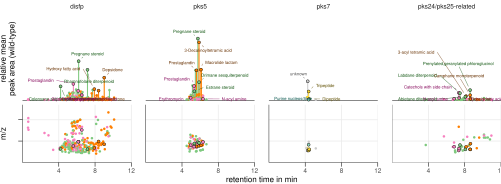

In [25]:
options(repr.plot.width = 15, repr.plot.height = 8)

# Label replacements for plot faceting
rename_metaChange_pks_dict <- list(
  "veg" = "vegetative cells",
  "stv" = "starved cells",
  "fbs" = "fruiting bodies",
  "Alkaloids" = "Alkaloids",
  "Amino acids and Peptides" = "Amino acids and \n Peptides",
  "Carbohydrates" = "Carbohydrates",
  "Fatty acids" = "Fatty acids",
  "unknown" = "unknown",
  "Polyketides" = "Polyketides",
  "Shikimates and Phenylpropanoids" = "Shikimates and \n Phenylpropanoids",
  "Terpenoids" = "Terpenoids"
)

labeller <- function(variable, value) rename_metaChange_pks_dict[value]

# Define colors
NPC_pathway.colors <- c(
  "Alkaloids" = "#8DD3C7",
  "Amino acids and Peptides" = "#FFD92F",
  "Carbohydrates" = "#386CB0",
  "Fatty acids" = "#F781BF",
  "unknown" = "#CCCCCC",
  "Polyketides" = "#FF7F00",
  "Shikimates and Phenylpropanoids" = "#A6761D",
  "Terpenoids" = "#7FC97F"
)

# Generate darker variant of colors for labeling
NPC_pathway.colors.dark <- darken(NPC_pathway.colors, amount = 0.6)
names(NPC_pathway.colors.dark) <- paste0(names(NPC_pathway.colors), "_dark")

# Define grouping of interest
pks_list <- c("disfp", "pks5", "pks7", "pks24/pks25-related")

# Select and prepare feature table
ft_selected <- ft_abs %>%
  mutate(metaChange_pks = case_when(
    metaChange_pks %in% c("pks24", "pks25", "pks24andpks25", "pks2425", "pks24_pks25_pks2425") ~ "pks24/pks25-related",
    TRUE ~ metaChange_pks
  )) %>%
  filter(stage == "fbs") %>%
  filter(metaChange_pks %in% pks_list) %>%
  filter(sirius_NPC.pathway %in% c("Polyketides", "Fatty acids", "Terpenoids") | metaChange_pks == "pks7")

# Identify top_n features by mean intensity per group and pathway
top_n <- 3
top_features <- ft_selected %>%
  filter(sirius_NPC.pathway %in% NPC_pathway.levels) %>%
  group_by(metaChange_pks, sirius_NPC.pathway) %>%
  arrange(desc(wt_mean)) %>%
  distinct(sirius_NPC.class, .keep_all = TRUE) %>%
  slice_head(n = top_n) %>%
  pull(feature)

# Annotate feature table
ft_selected <- ft_selected %>%
  filter(sirius_NPC.pathway %in% NPC_pathway.levels) %>%
  mutate(
    NPC_pathway.levels = factor(sirius_NPC.pathway, levels = NPC_pathway.levels),
    top_n_flag = feature %in% top_features
  ) %>%
  arrange(metaChange_pks, top_n_flag, desc(wt_mean))

# Intensity plot
npc_plot_pks_int <- ft_selected %>%
  mutate(metaChange_pks = factor(metaChange_pks, levels = pks_list)) %>%
  ggplot(aes(x = rt, y = wt_mean)) +
  geom_segment(aes(x = rt, y = -250000, yend = wt_mean, color = sirius_NPC.pathway), linewidth = 0.5) +
  annotate("segment", x = 0, xend = 12, y = -250000, yend = -250000, color = "black", linewidth = 0.2) +
  geom_point(shape = 21, color = "black", size = 1.2,
             aes(stroke = ifelse(top_n_flag, 0.3, 0), fill = sirius_NPC.pathway)) +
  geom_text_repel(
    data = ~.x %>% filter(top_n_flag),
    aes(
      label = str_replace(sub("s$", "", sirius_NPC.class), " and derivatives", ""),
      color = paste0(sirius_NPC.pathway, "_dark")
    ),
    size = 1.5,
    box.padding = 0.3,
    point.padding = 0.5,
    segment.alpha = 0.75,
    segment.size = 0.2,
    max.overlaps = Inf,
    force = 100,
    force_pull = 2,
    min.segment.length = 0
  ) +
  scale_fill_manual(values = NPC_pathway.colors) +
  scale_color_manual(values = c(NPC_pathway.colors, NPC_pathway.colors.dark)) +
  facet_grid(~ metaChange_pks, switch = "y", space = "free_y", drop = FALSE) +
  scale_y_continuous(labels = NULL) +
  scale_x_continuous(breaks = NULL, limits = c(0, 12), expand = c(0, 0)) +
  coord_cartesian(ylim = c(NA, 3e7)) +
  labs(x = NULL, y = "relative mean \npeak area (wild-type)") +
  theme_minimal(base_size = 8) +
  theme(
    strip.placement = "outside",
    strip.text.y.left = element_text(angle = 0, hjust = 1),
    panel.spacing.y = unit(0, "lines"),
    panel.spacing.x = unit(1, "lines"),
    panel.grid = element_blank(),
    strip.background = element_blank(),
    legend.position = "none"
  )

# m/z plot
npc_plot_pks_mz <- ft_selected %>%
  mutate(metaChange_pks = factor(metaChange_pks, levels = pks_list)) %>%
  ggplot(aes(x = rt, y = mz)) +
  annotate("segment", x = 0, xend = 12, y = 0, yend = 0, color = "black", linewidth = 0.2) +
  annotate("segment", x = 0, xend = 0, y = 0, yend = Inf, color = "black", linewidth = 0.2) +
  geom_point(shape = 21, color = "black", size = 1.2,
             aes(stroke = ifelse(top_n_flag, 0.3, 0), fill = sirius_NPC.pathway)) +
  scale_fill_manual(values = NPC_pathway.colors) +
  scale_color_manual(values = c(NPC_pathway.colors, NPC_pathway.colors.dark)) +
  facet_grid(~ metaChange_pks, switch = "y", space = "free_y", drop = FALSE) +
  scale_x_continuous(breaks = c(4, 8, 12), limits = c(0, 12), expand = c(0, 0)) +
  scale_y_continuous(breaks = c(500, 1000), limits = c(0, 1350), expand = c(0, NA), labels = NULL) +
  labs(x = "retention time in min", y = "m/z") +
  theme_minimal(base_size = 8) +
  theme(
    strip.placement = "outside",
    strip.text = element_blank(),
    panel.spacing.y = unit(0, "lines"),
    panel.spacing.x = unit(1, "lines"),
    panel.grid.minor = element_blank(),
    axis.ticks = element_line(color = "black", size = 0.25),
    axis.ticks.length = unit(0.15, "cm"),
    strip.background = element_blank(),
    legend.position = "none"
  )

# Combine plots
absent_pks_plot <- wrap_plots(npc_plot_pks_int, npc_plot_pks_mz, ncol = 1, heights = c(2, 1.25)) &
  theme(plot.margin = unit(c(0, 0, 0, 0), "cm"))

# Save SVG
save_path_svg <- file.path(wd, "05_results", "img", "absent_pks_plot.svg")
ggsave(
  filename = save_path_svg,
  plot = absent_pks_plot,
  width = 177, height = 65, units = "mm",
  bg = "transparent",
  device = svglite
)

# Display inline
display_svg(file = save_path_svg)
